<a href="https://colab.research.google.com/github/Anuska111/E-Commerce-Customer-Lifetime-Value-CLV-Segmentation/blob/main/E_Commerce_Customer_Lifetime_Value_(CLV)_%26_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [235]:
##Import Required Libraries
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns




In [236]:
##Load Dataset
df = pd.read_csv("/content/online_retail_II.csv.zip")

In [237]:
##Dataset Check
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [238]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [239]:
df.shape

(1067371, 8)

In [240]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [242]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [243]:
#Data Cleaning
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [244]:
df = df.dropna()

In [245]:
df.duplicated().sum()

np.int64(26479)

In [246]:
df = df.drop_duplicates()

In [247]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [248]:

df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

In [249]:
print(df[df["Invoice"].astype(str).str.startswith("C")].shape)
print(df[df["Quantity"] < 0].shape)
print(df[df["Price"] <= 0].shape)

(0, 8)
(0, 8)
(0, 8)


In [250]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [251]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [252]:
#Feature Engineering (RFM)
snapshot_date = df["InvoiceDate"].max()

In [253]:
rfm = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Revenue": "sum",
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days
}).reset_index()

In [254]:
rfm.columns = [
    "CustomerID",
    "Frequency",
    "Monetary",
    "Recency"]

In [255]:
rfm.head()

,CustomerID,Frequency,Monetary,Recency
0,12346.0,12,77556.46,325
1,12347.0,8,4921.53,1
2,12348.0,5,2019.40,74
3,12349.0,4,4428.69,18
4,12350.0,1,334.40,309


In [256]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

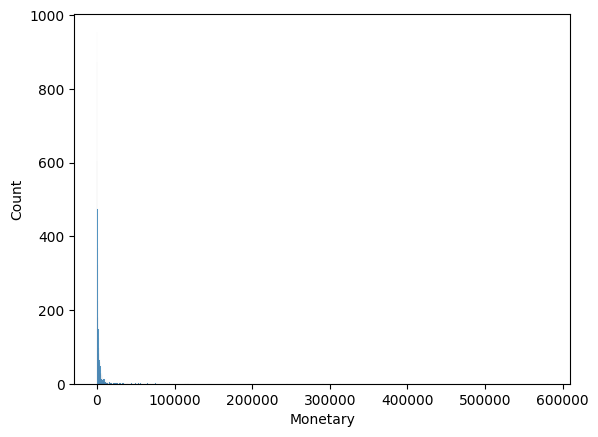

In [257]:
#Revenue Distribution
sns.histplot(rfm["Monetary"])

plt.show()

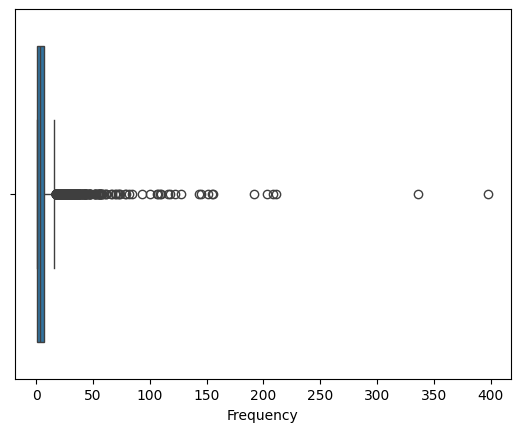

In [258]:
#Frequency Distribution
sns.boxplot(x=rfm["Frequency"])

plt.show()

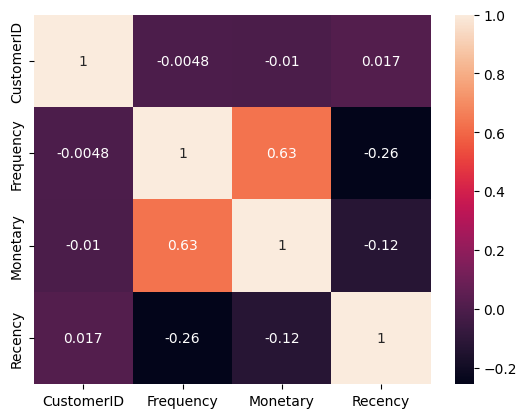

In [259]:
#Correlation
sns.heatmap(rfm.corr(), annot=True)

plt.show()

In [260]:
#Data Scaling
from sklearn.preprocessing import StandardScaler

In [261]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(

rfm[['Recency','Frequency','Monetary']]
)

In [262]:
#Customer Segmentation
from sklearn.cluster import KMeans

In [263]:
kmeans = KMeans(
n_clusters=4,
random_state=42
)
rfm["Cluster"] = kmeans.fit_predict(
scaled_data
)

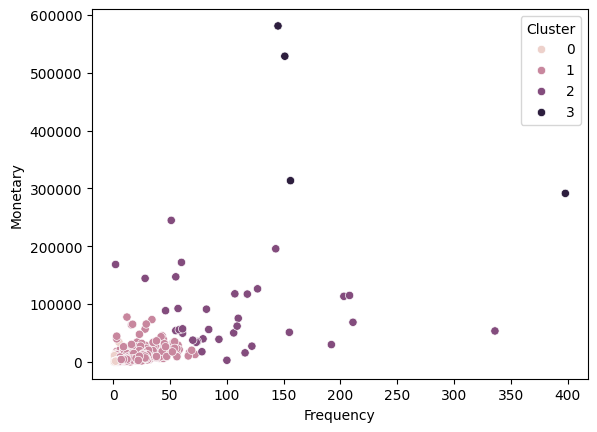

In [264]:
sns.scatterplot(
data=rfm,
x="Frequency",
y="Monetary",
hue="Cluster"
)
plt.show()

In [265]:
#Evaluate Clustering
from sklearn.metrics import silhouette_score

In [266]:
score = silhouette_score(
scaled_data,
rfm["Cluster"]
)
print(score)

0.5904005630682659


In [267]:
# Customer Segment Names

segment_names = {
    0: "At Risk Customers",
    1: "Active Customers"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(segment_names)

print(rfm[["Cluster", "CustomerSegment"]].head())

   Cluster    CustomerSegment
0        1   Active Customers
1        1   Active Customers
2        1   Active Customers
3        1   Active Customers
4        0  At Risk Customers


In [268]:
# Number of Customers in Each Segment

print(rfm["CustomerSegment"].value_counts())

CustomerSegment
Active Customers     3836
At Risk Customers    2003
Name: count, dtype: int64


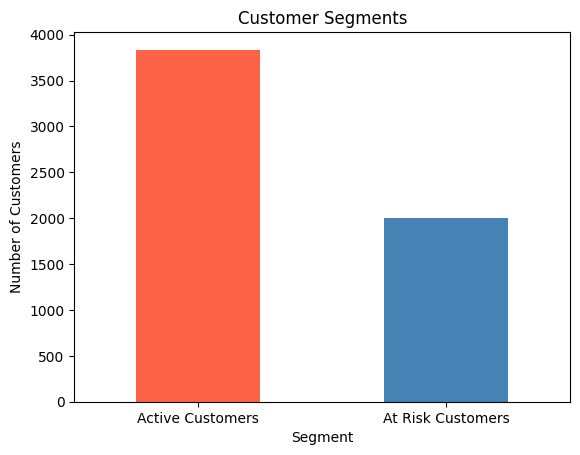

In [269]:
import matplotlib.pyplot as plt

rfm["CustomerSegment"].value_counts().plot(
    kind="bar",
    color=["tomato", "steelblue"]
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [270]:
# CREATE CLV
# Average Order Value
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

# Customer Life Span
rfm["CustomerLifeSpan"] = rfm["Recency"] + 1

# Purchase Rate
rfm["PurchaseRate"] = (
    rfm["Frequency"] / rfm["CustomerLifeSpan"])


In [271]:
# Customer Lifetime Value
rfm["CLV"] = (
    rfm["Frequency"]
    * rfm["AvgOrderValue"]
    * rfm["PurchaseRate"]
)

print(rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "PurchaseRate",
    "CLV"
]].head())

   Recency  Frequency  Monetary  AvgOrderValue  PurchaseRate           CLV
0      325         12  77556.46    6463.038333      0.036810   2854.839018
1        1          8   4921.53     615.191250      4.000000  19686.120000
2       74          5   2019.40     403.880000      0.066667    134.626667
3       18          4   4428.69    1107.172500      0.210526    932.355789
4      309          1    334.40     334.400000      0.003226      1.078710


In [272]:
# REMOVE OUTLIERS
Q1 = rfm["CLV"].quantile(0.25)
Q3 = rfm["CLV"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rfm = rfm[
    (rfm["CLV"] >= lower) &
    (rfm["CLV"] <= upper)]


In [273]:
# FEATURES & TARGET
rfm["LogFrequency"] = np.log1p(rfm["Frequency"])
rfm["LogRecency"] = np.log1p(rfm["Recency"])

X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "LogFrequency",
        "LogRecency"]]

y = rfm["CLV"]


In [274]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [275]:
# TRAIN MODEL
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)



RandomForestRegressor(n_estimators=200, random_state=42)

In [276]:
# PREDICTION
prediction = model.predict(X_test)


In [277]:
# EVALUATION
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error)
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, prediction))
r2 = r2_score(
    y_test,
    prediction)

mape = mean_absolute_percentage_error(
    y_test,
    prediction) * 100


In [278]:
print("RMSE :", rmse)
print("R2 Score :", r2)
print("MAPE :", mape)

RMSE : 36.583005513010484
R2 Score : 0.9541411195047689
MAPE : 7.933963011327452


In [279]:
print("y_test :", len(y_test))
print("prediction :", len(prediction))

y_test : 959
prediction : 959


In [280]:
print(X.columns)

Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')


Monetary        0.223937
LogFrequency    0.215977
Recency         0.192585
LogRecency      0.185709
Frequency       0.181791
dtype: float64


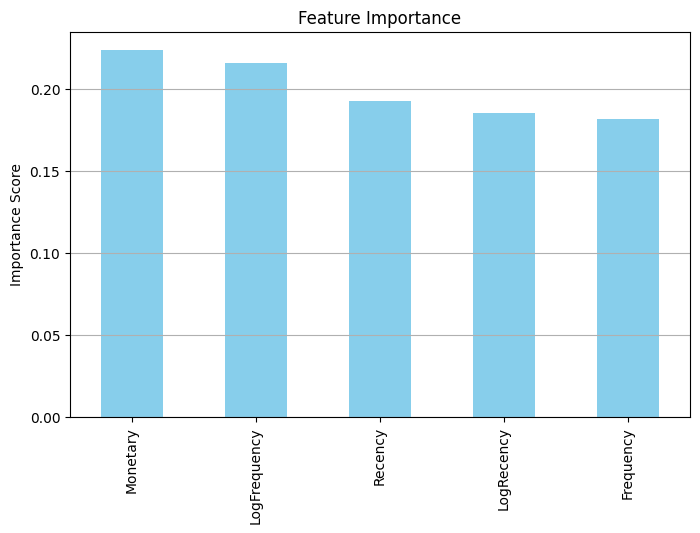

In [281]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar", color="skyblue")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.grid(axis="y")
plt.show()

In [282]:
result = pd.DataFrame({
    "Actual CLV": y_test,
    "Predicted CLV": prediction})

result.head(10)

,Actual CLV,Predicted CLV
715,14.142761,13.824340
1124,9.842988,10.288734
2096,174.835425,162.557112
901,75.187516,67.892395
2331,480.634375,468.519462
3327,0.711940,0.723308
3711,0.158879,0.434190
5510,2.373593,2.559930
934,3.888507,4.313173
43,6.873000,7.653692


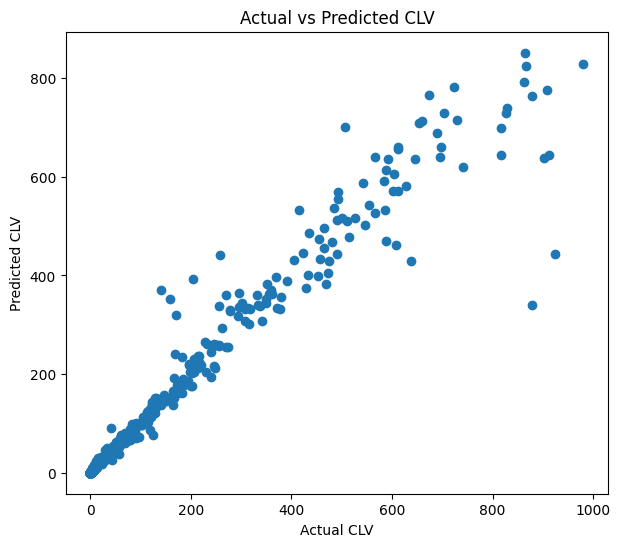

In [283]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
plt.scatter(y_test, prediction)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

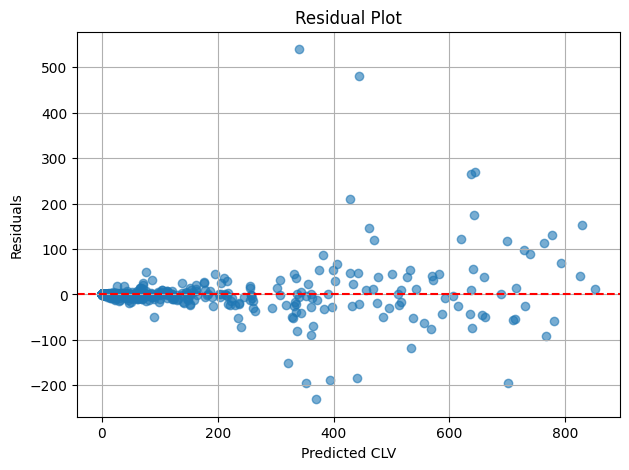

In [284]:
#Residual Plot
import matplotlib.pyplot as plt

residuals = y_test - prediction

plt.figure(figsize=(7,5))

plt.scatter(prediction, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted CLV")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [285]:
print(rfm["CLV"].describe())

count    4793.000000
mean       94.717338
std       186.111136
min         0.004080
25%         1.396438
50%        10.669950
75%        83.181818
max       990.862222
Name: CLV, dtype: float64


In [286]:
import pandas as pd
import numpy as np

# User Input
recency = 10
frequency = 15
monetary = 25000   # Total amount spent by customer

# Create New Customer Features
new_customer = pd.DataFrame({
    "Recency": [recency],
    "Frequency": [frequency],
    "Monetary": [monetary],
    "LogFrequency": [np.log1p(frequency)],
    "LogRecency": [np.log1p(recency)]
})

# Predict CLV
predicted_clv = model.predict(new_customer)

print(f"Predicted Customer Lifetime Value (CLV): {predicted_clv[0]:.2f}")

Predicted Customer Lifetime Value (CLV): 941.54


In [287]:
print(rfm["CLV"].describe())

count    4793.000000
mean       94.717338
std       186.111136
min         0.004080
25%         1.396438
50%        10.669950
75%        83.181818
max       990.862222
Name: CLV, dtype: float64


In [288]:
##Dashboard (Streamlit)
#Save Model
import joblib
joblib.dump(model, "clv_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [289]:
#Save RFM Dataset
rfm.to_csv("rfm.csv", index=False)

In [290]:
##Dashboard Section
#Dashboard Heading
print("="*60)
print("E-Commerce Customer Dashboard")
print("="*60)

E-Commerce Customer Dashboard


In [291]:
#Business Summary
print("Total Customers :", len(rfm))
print("Average CLV :", round(rfm["CLV"].mean(),2))
print("Maximum CLV :", round(rfm["CLV"].max(),2))
print("Minimum CLV :", round(rfm["CLV"].min(),2))

Total Customers : 4793
Average CLV : 94.72
Maximum CLV : 990.86
Minimum CLV : 0.0


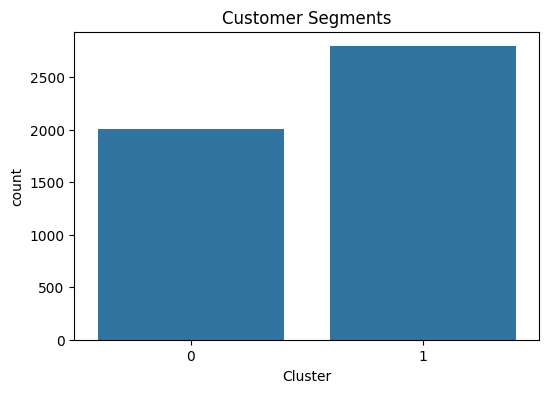

In [292]:
#Cluster Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(
    data=rfm,
    x="Cluster")
plt.title("Customer Segments")
plt.show()

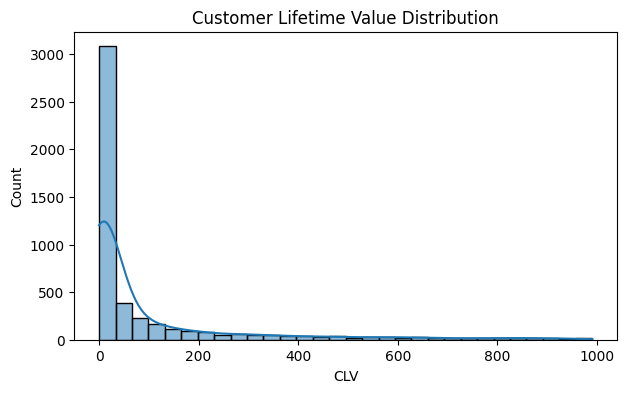

In [293]:
#CLV Distribution
plt.figure(figsize=(7,4))
sns.histplot(
    rfm["CLV"],
    bins=30,
    kde=True)
plt.title("Customer Lifetime Value Distribution")
plt.show()

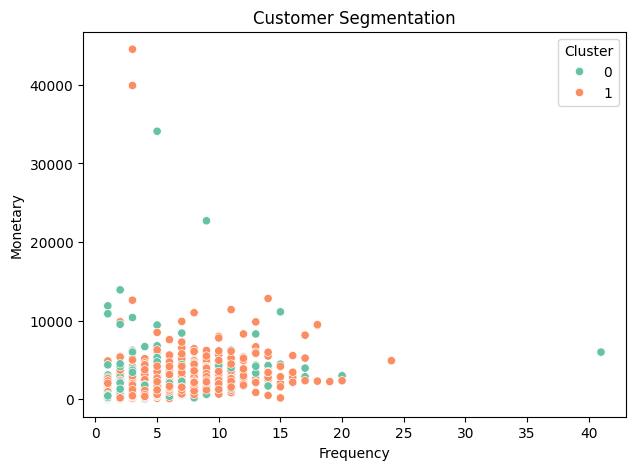

In [294]:
#Customer Segmentation
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2")
plt.title("Customer Segmentation")
plt.show()

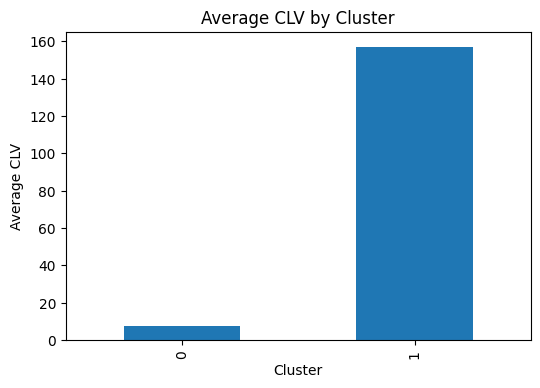

In [295]:
#Average CLV by Cluster
cluster_clv = rfm.groupby("Cluster")["CLV"].mean()
cluster_clv.plot(
    kind="bar",
    figsize=(6,4))
plt.title("Average CLV by Cluster")
plt.ylabel("Average CLV")
plt.show()

In [296]:
#Top 10 Customers
rfm.sort_values(
    by="CLV",
    ascending=False
).head(10)

,CustomerID,Frequency,Monetary,Recency,Cluster,CustomerSegment,AvgOrderValue,CustomerLifeSpan,PurchaseRate,CLV,LogFrequency,LogRecency
1149,13509.0,8,1114.72,8,1,Active Customers,139.340000,9,0.888889,990.862222,2.197225,2.197225
4548,16940.0,8,6427.66,51,1,Active Customers,803.457500,52,0.153846,988.870769,2.197225,3.951244
4031,16416.0,9,2957.88,26,1,Active Customers,328.653333,27,0.333333,985.960000,2.302585,3.295837
2725,15101.0,6,1477.94,8,1,Active Customers,246.323333,9,0.666667,985.293333,1.945910,2.197225
3140,15518.0,15,4189.99,63,1,Active Customers,279.332667,64,0.234375,982.028906,2.772589,4.158883
2990,15367.0,11,5081.33,56,1,Active Customers,461.939091,57,0.192982,980.607544,2.484907,4.043051
3480,15860.0,17,2361.30,40,1,Active Customers,138.900000,41,0.414634,979.075610,2.890372,3.713572
3293,15671.0,7,2657.13,18,1,Active Customers,379.590000,19,0.368421,978.942632,2.079442,2.944439
2390,14759.0,3,1625.97,4,1,Active Customers,541.990000,5,0.600000,975.582000,1.386294,1.609438
4596,16989.0,6,1133.25,6,1,Active Customers,188.875000,7,0.857143,971.357143,1.945910,1.945910


In [297]:
#: Cluster Summary
rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean",
    "CLV":"mean"})

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,461.443278,2.178411,730.882750,7.400827
1,83.606734,4.004298,1316.079487,157.296256


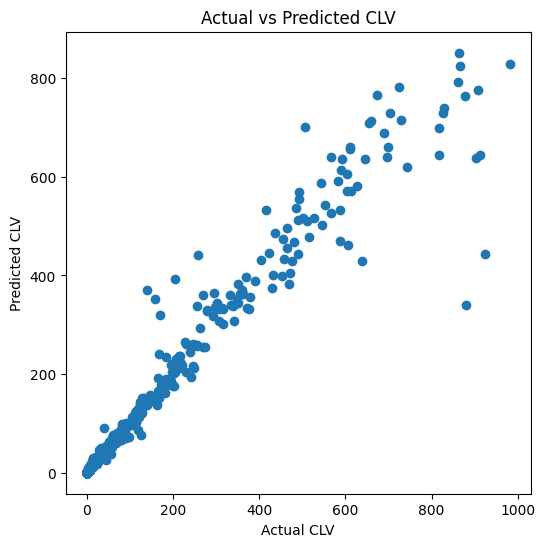

In [298]:
plt.figure(figsize=(6,6))
plt.scatter(
    y_test,
    prediction)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

In [299]:
#Feature Importance
importance = pd.DataFrame({
     "Feature":X.columns,
     "Importance":model.feature_importances_})
importance.sort_values(
    by="Importance",
    ascending=False)

,Feature,Importance
2,Monetary,0.223937
3,LogFrequency,0.215977
0,Recency,0.192585
4,LogRecency,0.185709
1,Frequency,0.181791


In [300]:
import pandas as pd
import numpy as np

# Customer Input
recency = 10
frequency = 5
monetary = 1200

# Log Features
log_frequency = np.log1p(frequency)
log_recency = np.log1p(recency)

# Create DataFrame (same columns as X)
new_customer = pd.DataFrame({
    "Recency": [recency],
    "Frequency": [frequency],
    "Monetary": [monetary],
    "LogFrequency": [log_frequency],
    "LogRecency": [log_recency]
})

# Predict CLV
predicted_clv = model.predict(new_customer)

print(f"Predicted Customer Lifetime Value (CLV): {predicted_clv[0]:.2f}")

Predicted Customer Lifetime Value (CLV): 434.62


In [301]:
print(X.columns)
print(new_customer.columns)

Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')
Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')


In [302]:
print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("High Value Customers")
print("- Premium Offers")
print("- Loyalty Rewards")
print("- Exclusive Discounts\n")

print("Regular Customers")
print("- Personalized Recommendations")
print("- Email Marketing")
print("- Cross Selling\n")

print("At Risk Customers")
print("- Win-back Campaigns")
print("- Coupons")
print("- Reminder Emails")

========== BUSINESS RECOMMENDATIONS ==========

High Value Customers
- Premium Offers
- Loyalty Rewards
- Exclusive Discounts

Regular Customers
- Personalized Recommendations
- Email Marketing
- Cross Selling

At Risk Customers
- Win-back Campaigns
- Coupons
- Reminder Emails


In [303]:
import joblib

joblib.dump(model, "clv_model.pkl")

['clv_model.pkl']

In [304]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)

print("Cross-validation RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())


Cross-validation RMSE scores: [28.96801175 39.81379483 32.988624   33.39525841 39.87644342]
Average RMSE: 35.00842648111917
